# Analyse the cadence of walking using IMU data and dsSST algorithm

This notebook performs the following steps to analyze the cadence of walking using IMU data:
1. Upload the library and configure the analysis parameters, including the sampling frequency and figure display settings.
2. Load the dataset and processing the IMU signals.


This work have been made with the utilisation of Claude IA and Co Pilot IA.

The time frequency  analysis is performed using the deshape synchrosqueezing transform (dsSST) algorithm, which allows us to extract the fundamental frequency of walking from the accelerometer signals. The construction of the pipeline is made from the article of Wu et Harezlak, « Application of de-shape synchrosqueezing to estimate gait cadence from a single-sensor accelerometer placed in different body locations ».

The pipeline is made with the synchrosqueezing function created by John Muradeli, ssqueezepy, 2020. GitHub repository, https://github.com/OverLordGoldDragon/ssqueezepy/. DOI: 10.5281/zenodo.5080508  

This notebook is working with the daraset provided by Zhou et al., « Dataset for Monitoring and Visualizing Stroke Rehabilitation Progress using Wearable Sensors (IMU) ». The patient walked with an IMU sensor on their wrist/feet/sacrum, and the data was collected during different visits. The goal of this analysis is to extract the fundamental frequency information from the IMU signals .  
  

The directory structure of the project is inspired by the work  Victor Fernando Lopes De Souza's activity_acc_clustering directory.



## 1. Import & Configuration
### *a)* Import the library  

In [1]:
# ------------------a) Import the necessary libraries------------------*
import os
import sys 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# if needed, install the required libraries using pip
# !pip install matplotlib
# !pip install numpy
# !pip install pandas
# !pip install pathlib

#install the dsSST library from the GitHub repository of 

### *b)* Create the path for the project resources (data, modules, results)  

In [2]:
# ------------------b) The path for the project resources (data, modules, results)-------------------
"""
We have segmented the project into different directories to keep it organised. 
The project root is the base directory that contains all the other directories, a folder structure for the data and the project is available in project_root. 
The module directory is where we will place our custom Python modules, and the data directory is where we will store our datasets. 
The results directory is where we will save any outputs or visualisations generated from our analysis.
"""

# Define the project root, module, and data directories
project_root = os.path.abspath('../..')
module_dir = os.path.join(project_root, 'python_Movement_analysis_project/module')
data_dir = os.path.join(project_root, 'python_Movement_analysis_project/data/imu0001')
participant_file = os.path.join(data_dir, 'participant_info.csv')
results_dir = os.path.join(project_root, 'results')


# the following lines add the project root and module directories to the Python path, allowing you to import custom modules from those locations
if project_root not in sys.path:
	sys.path.append(project_root)
if module_dir not in sys.path:
	sys.path.append(module_dir)

# Import custom modules 
import dsSST
import handle_data

### *c)* Establish the parameters for the analysis, such as the sampling frequency and the sensors to analyze.  

In [3]:
# ------------------c) Parameter for this analysis-------------------

# frequency of the data acquisition (sampling frequency) cf Zhou et al., « Monitoring and Visualizing Stroke Rehabilitation Progress using Wearable Sensors ».
fs = 120  # Hz

# Sensors to analyze displayed in a list 
SENSORS = ["LF", "RF", "LW", "RW", "SA"]

# dsSST parameters (default values from the article Wu & Lin)
DSSST_PARAMS = dict(
    gamma=1e-9,
    lambda_reg=10**-3,
    lifter_threshold=60,
    window_length_s=12,   # STFT window size in seconds
)

# parameters for the visualization of the results
# Enable/disable figures per recording (can become heavy on large cohorts)
SAVE_FIGURES = True
SHOW_FIGURES_INLINE = True   # display in the notebook
MAX_INLINE_FIGURES = 1       # limit inline display to avoid overloading the notebook


## 2. Data extraction and processing
### *a)* data extarction with find_patient_visits function to get the list of patient visits and their corresponding data files. 
In the module handle_data, the function find_patient_visits scans the data directory for files and organizes them into a structured format (e.g., a dictionary or DataFrame) .  

In [4]:
#------------------a) data extraction ------------------
"""The first step in our analysis is to extract the relevant data from the dataset.
    ----------------------------INPUT----------------------------
    data_root: Path to the root directory of the dataset, which contains the patient directories (imuXXXX).
    ----------------------------OUTPUT----------------------------
    A list of dictionaries, each containing {patient_id, visit, imu_dir} for each valid patient visit found in the dataset.
"""

# Step 1 : Found the visits (use  find_patient_visits from the handle_data module)
Information_data_extraction = handle_data.find_patient_visits(Path(data_dir))
print(f"→ {len(Information_data_extraction)} visits found in the dataset")

# Step 2 : for each visit, list the expected sensors
recordings = []

for v in Information_data_extraction:
    for sensor in SENSORS:
        csv_path = v["imu_dir"] / f"{sensor}.csv"
        recordings.append({
            "visit":      v["visit"],
            "sensor":     sensor,
            "csv_path":   csv_path,
            "file_found": csv_path.exists(),
        })

# Visual summary of the data extraction step
n_total = len(recordings)
n_found = sum(r["file_found"] for r in recordings)
print(f"→ {n_found}/{n_total} fichiers CSV trouvés sur disque")

→ 2 visits found in the dataset
→ 10/10 fichiers CSV trouvés sur disque


### *b)* process the IMU signal to extract the Norm of acceleration and the time with the fucntion load_acc_norm.
From the data files found previously, the function load_acc_norm reads the accelerometer data, computes the norm of the acceleration , and extracts the corresponding time values.

In [5]:
#------------------b) process the IMU signal to extract the norm of acceleration and the time------------------
"""The next step is to process the IMU signal to extract the norm of acceleration and the corresponding time values.
    ----------------------------INPUT----------------------------
    csv_path: Path to the csv file containing the raw data of the IMU sensor, which should be contained in the columns "timestamp", "accx", "accy", "accz"
    ----------------------------OUTPUT----------------------------
    ts: numpy array containing the time of the IMU sensor, extracted from the "timestamp" column of the csv file.
    norm: numpy array containing the norm of the acceleration, computed from the "accx", "accy", "accz" columns of the csv file.
"""
    # First initialise the fields for each recording in the list of recordings, setting default values for the time series (ts), norm of acceleration (norm)
for rec in recordings:
    rec["ts"]         = None
    rec["norm"]       = None
    rec["n_samples"]  = np.nan
    rec["duration_s"] = np.nan
    rec["error"]      = ""

    # load the information need for the analysis
    try:
        ts, norm = handle_data.load_acc_norm(rec["csv_path"])
        rec["ts"]         = ts
        rec["norm"]       = norm
        rec["n_samples"]  = len(norm)
        rec["duration_s"] = len(norm) / fs


    except Exception as e:
        rec["error"] = f"{type(e).__name__}: {e}"

# Summary
n_loaded = sum(r["norm"] is not None and r["error"] == "" for r in recordings)
print(f"→ {n_loaded}/{n_total} signals loaded and usable")
print(f"→ {n_total - n_loaded} signals with errors (missing file, loading error, etc.)")

→ 10/10 signals loaded and usable
→ 0 signals with errors (missing file, loading error, etc.)


### *c)* Compute the time frequency analysis using the deshape synchrosqueezing transform (dsSST) with the function Time_frequency_analyse.
The function Time_frequency_analyse takes the norm of the acceleration and the time values as input and applies the dsSST algorithm to compute the time-frequency representation of the signal. This will give us the Short time Fourier transform of the signal, and the deshape synchrosqueezing transform of the signal, which will be used to extract the cadence information.  
Another function to illustrate the results of the analysis has been used is the compute_plot. It will save a figure for every patient with the norm of acceleration, the STFT and the dsSST. 

In [6]:
#------------------c) Compute the time frequency analysis------------------
"""The next step is to compute the time-frequency analysis of the acceleration signal combining with a illustration of the results
   -----------------------------INPUT----------------------------
    signal_norm: numpy array containing the norm of the acceleration, computed from the "accx", "accy", "accz" columns of the csv file.
    fs: sampling frequency of the IMU sensor
    dsSST_parameters : parameter to compute the deshape synchrosqueezing transform.
        It should contain the following keys:
        - "gamma": the gamma parameter of the dsSST is the threshold for the synchrosqueezing step
        - "lambda_reg": penelization parameter for the extraction by recurence 
        - "lifter_threshold": the threshold for the liftering step, which is used to remove the low quefrency components of the signal.
        - "window_length_s": the length of the window used for the short-time Fourier transform (STFT) in seconds.
    -----------------------------OUTPUT----------------------------
    A dictionary containing the following keys:
    - "peak_frequency_hz": the fundamental frequency of the walk, extracted from the deshape synchrosqueezing transform of the signal.
    - "V_Zxx": the deshape synchrosqueezing transform of the signal, which is a time-frequency representation of the signal.
    - "V_f": the frequency axis of the deshape synchrosqueezing transform
    - "V_t": the time axis of the deshape synchrosqueezing transform
    - "Tx": the time-frequency representation of the signal obtained by applying the deshape synchrosqueezing transform
    - "freq_axis": the frequency axis of the deshape synchrosqueezing transform
    A figure illustrating the results of the analysis, which will be saved on the result directory for every patient
    - "fig"= the illustration of the norm of acceleration , the STFT, the dsSST. The number shawn in control by

"""

inline_count = 0

for rec in recordings:
    rec["peak_frequency_hz"] = None
    rec["analysis"]     = None

    # Skip si problème détecté à l'étape précédente
    if rec["error"] != "" or rec["norm"] is None:
        continue

    visit, sensor = rec["visit"], rec["sensor"]

    try:
        # ----- Analyse dsSST -----
        analysis = handle_data.Time_frequency_analyse(
            rec["norm"], fs, **DSSST_PARAMS
        )
        if analysis is None:
            rec["error"] = "dsSST returned None"
            continue

        rec["analysis"]      = analysis
        rec["peak_frequency_hz"]  = analysis["peak_frequency_hz"]

    except Exception as e:
        rec["error"] = f"{type(e).__name__}: {e}"
        print(f" {visit}/{sensor}: {rec['error']}")

# print only the 5 first results to check the output and the 5 last results 
for rec in recordings:
    print(f"{rec['visit']} / {rec['sensor']} : "
          f"f₀={rec['peak_frequency_hz']:.3f} Hz")



c:\Users\kapla\Documents\r et python\algorithm\algorithm de marche\LAMBERT_CAMILLE\python_Movement_analysis_project/module\dsSST.py:131: RuntimeWarning: divide by zero encountered in divide
  U=interpolate.interp1d(q_axis, C_lifted, axis=0, bounds_error=False, fill_value=0)((1.0 / V_f))


visit1 / LF : f₀=0.833 Hz
visit1 / RF : f₀=0.833 Hz
visit1 / LW : f₀=0.833 Hz
visit1 / RW : f₀=0.833 Hz
visit1 / SA : f₀=0.500 Hz
visit2 / LF : f₀=0.833 Hz
visit2 / RF : f₀=0.833 Hz
visit2 / LW : f₀=0.583 Hz
visit2 / RW : f₀=0.833 Hz
visit2 / SA : f₀=0.833 Hz


### *d)* Make a visualisation of the result for the right foot of the application of the de shape synchrosqueezing transform (dsSST) to the accelerometer signal the first visit of the patient. 

The figure will show the norm of acceleration, the STFT and the dsSST, with a focus on the frequency range of interest (0-5 Hz). The figure will be saved in the results folder for further analysis and comparison with other visits and patients.  
  
The aim of this visualisation is not to be exhautive of all the result of the time frequency analysis of every sensor . But to illustrate by a exemple the major step of this methodology.

Figure saved : c:\Users\kapla\Documents\r et python\algorithm\algorithm de marche\LAMBERT_CAMILLE\results\RF_visit1_analysis.png


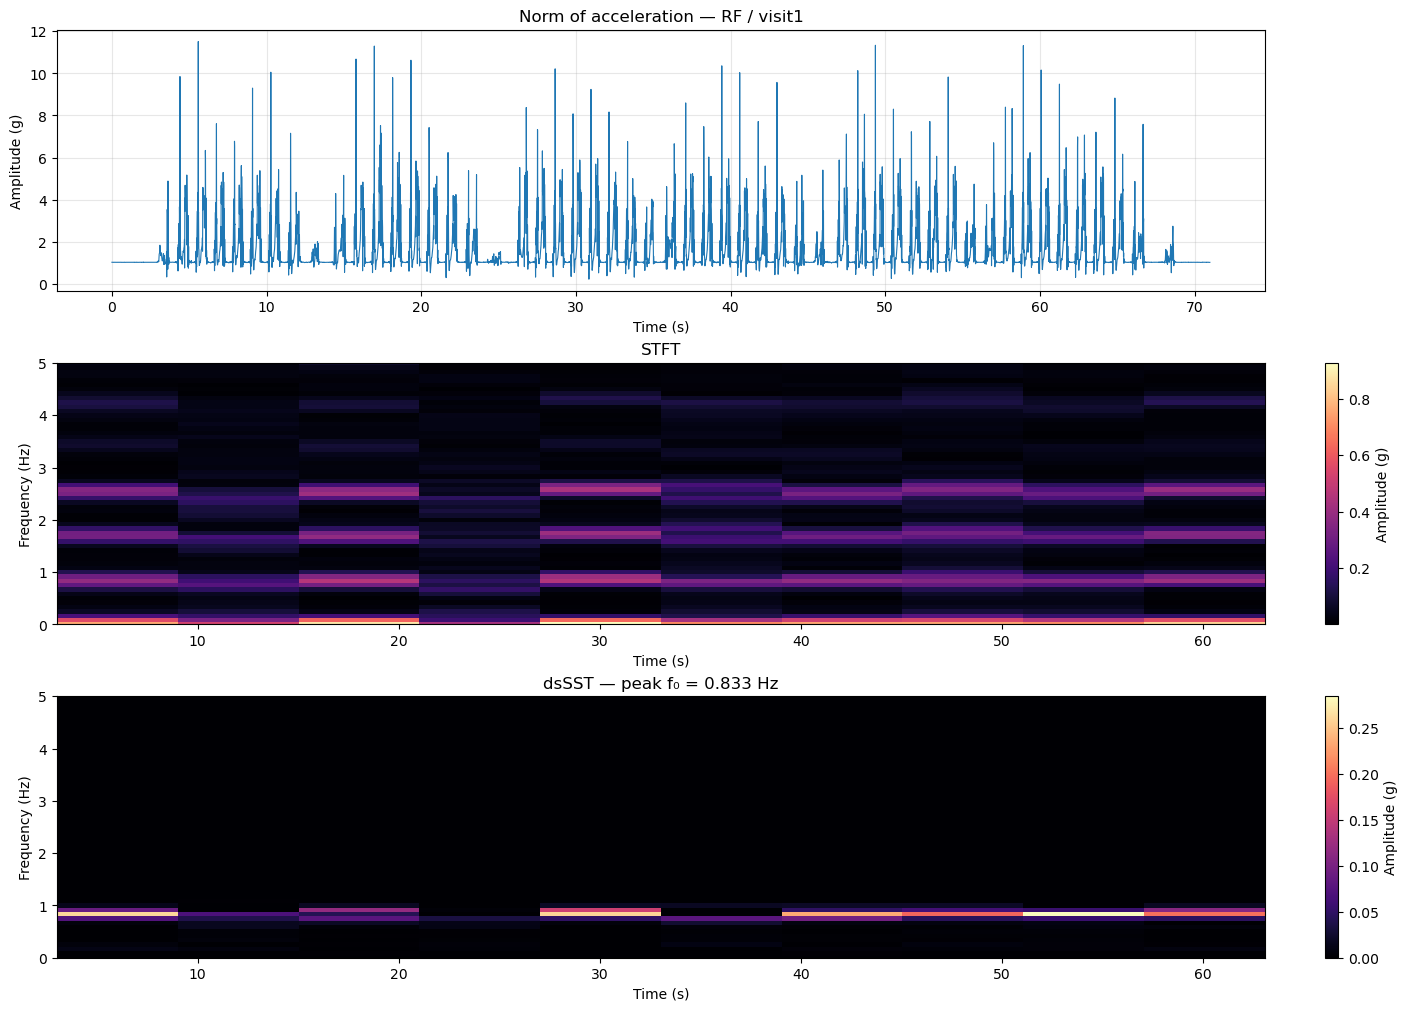

In [7]:
#------------------d) perform the visualisation of the signal propcessing of the time frequency analyse on the right foot------------------
"""
this step aim is to visualize the time frequency representation of the signal for the right foot (RF) during the first visit (visit1).
   -----------------------------INPUT----------------------------
    recordings: list of dictionaries containing the information about the recordings, including the norm of acceleration and the analysis results for each recording.
    fs: sampling frequency of the IMU sensor
    output_dir: directory where the figures will be saved
    -----------------------------OUTPUT----------------------------
    plot showing the norm of acceleration, the STFT and the dsSST for the right foot during the first visit.
    The saving of this figure in the result directory.
    """
# focus on the right foot (RF) during the first visit (visit1)
rec_target = next(
    (r for r in recordings 
     if r["visit"] == "visit1" and r["sensor"] == "RF" and r["analysis"] is not None),
    None
)
# Retrieve the data
norm     = rec_target["norm"]
analysis = rec_target["analysis"]
t        = np.arange(len(norm)) / fs               # time vector in seconds


# Step 2 : create the figure with 3 stacked subplots (3 rows × 1 column)
fig, axes = plt.subplots(3, 1, figsize=(14, 10), constrained_layout=True)

# ---- Subplot 1 : norm of acceleration ----
axes[0].plot(t, norm, color='tab:blue', linewidth=0.8)
axes[0].set_title("Norm of acceleration — RF / visit1")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Amplitude (g)")
axes[0].grid(alpha=0.3)

# ---- Subplot 2 : STFT (V_Zxx) ----
V_Zxx = analysis["V_Zxx"]
V_t   = analysis["V_t"]
V_f   = analysis["V_f"]

img1 = axes[1].pcolormesh(
    V_t, V_f, np.abs(V_Zxx),                        # the amplitude of STFT is used in the visualization
    shading='auto', cmap='magma'
    )
axes[1].set_title("STFT")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Frequency (Hz)")
axes[1].set_ylim(0, 5)                              # focusing on the physiologically relevant frequency  (0-5 Hz)
fig.colorbar(img1, ax=axes[1], label="Amplitude (g)")

# ---- Subplot 3 : dsSST (Tx) ----
Tx        = analysis["Tx"]
freq_axis = analysis["freq_axis"]

img2 = axes[2].pcolormesh(
    V_t, freq_axis, np.abs(Tx),                        # the amplitude of dsSST is used in the visualization
    shading='auto', cmap='magma'
    )
axes[2].set_title(f"dsSST — peak f₀ = {rec_target['peak_frequency_hz']:.3f} Hz")
axes[2].set_xlabel("Time (s)")
axes[2].set_ylabel("Frequency (Hz)")
axes[2].set_ylim(0, 5)                              # focusing on the physiologically relevant frequency  (0-5 Hz)
fig.colorbar(img2, ax=axes[2], label="Amplitude (g)")

# Optionally : save the figure
save_path = Path(results_dir) / "RF_visit1_analysis.png"
fig.savefig(save_path, dpi=150, bbox_inches='tight')
print(f"Figure saved : {save_path}")

plt.show()

### *e)* Create a summary file with the frequency information and the FAC score for every patient visit. 
This file will be used for the statistical analysis in R. The summary file will contain the following columns for every patient visit:
    - "patient_id": the ID of the patient  
    - "visit": the visit number (e.g., 1, 2, 3)  
    - "sensor": the sensor used for the measurement  
    - "duration_s": the duration of the walking trial in seconds  
    - "peak_frequency_hz": the estimated fondamental frequency of walking, extracted from the time-frequency representation of the signal  
    - "FAC": the Functional Ambulation Category score of the patient, imported from the dataset

In [8]:
#------------------e) Creating a file with the results------------------
"""
In this final step, we will create a summary file that contains the results of our analysis, including the peak frequency extracted from the dsSST analysis for each patient and visit.
    -----------------------------INPUT----------------------------
    recordings: A list of dictionaries, each containing the results of the analysis for each recording, including the patient_id, visit, sensor, peak frequency
    results_dir: Path to the directory where the summary file will be saved
    -----------------------------OUTPUT----------------------------
    A CSV file containing the summary of the analysis, including the peak frequency for each patient and visit.

"""

summary_cols = [ "visit", "sensor", "peak_frequency_hz"]
df_results = pd.DataFrame([
    {k: r[k] for k in summary_cols} for r in recordings
])

csv_out = Path(results_dir) / "frequency_summary.csv"
df_results.to_csv(csv_out, index=False)
print(f"Register frame : {csv_out}")
df_results.head(10)

Register frame : c:\Users\kapla\Documents\r et python\algorithm\algorithm de marche\LAMBERT_CAMILLE\results\frequency_summary.csv


,visit,sensor,peak_frequency_hz
0,visit1,LF,0.832755
1,visit1,RF,0.832755
2,visit1,LW,0.832755
3,visit1,RW,0.832755
4,visit1,SA,0.499653
5,visit2,LF,0.832755
6,visit2,RF,0.832755
7,visit2,LW,0.582929
8,visit2,RW,0.832755
9,visit2,SA,0.832755
